In [2]:
import pandas as pd

test_df = pd.read_parquet("../data/processed/splits/test.parquet")

X_test = test_df["text"]
y_test = test_df["sentiment"]

In [3]:
import joblib

bundle = joblib.load("../models/ml/tfidf_logreg.joblib")

model = bundle["model"]
tfidf = bundle["vectorizer"]

In [4]:
X_test_tfidf = tfidf.transform(X_test)

In [5]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.34      0.35      0.34        81
     neutral       0.24      0.34      0.28        71
    positive       0.92      0.89      0.90       803

    accuracy                           0.80       955
   macro avg       0.50      0.52      0.51       955
weighted avg       0.82      0.80      0.81       955



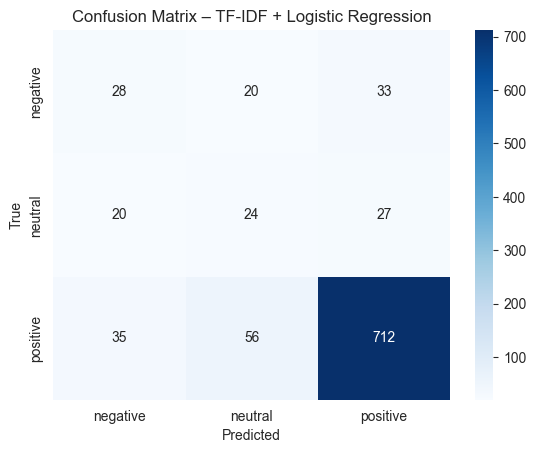

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – TF-IDF + Logistic Regression")
plt.show()

In [7]:
import numpy as np

feature_names = tfidf.get_feature_names_out()

for i, cls in enumerate(model.classes_):
    top = np.argsort(model.coef_[i])[-10:]
    print(f"\nTop features for class '{cls}':")
    print(feature_names[top])


Top features for class 'negative':
['guess' 'poor' 'didn' 'money' 'worst' 'pages' 'loud' 'just' 'boring'
 'waste']

Top features for class 'neutral':
['somewhat' 'thought' 'good just' 'bit' 'hoping' 'decent' 'nearly'
 'expected' 'difficult' 'little']

Top features for class 'positive':
['wait' 'highly' 'perfect' 'loves' 'beautiful' 'wonderful' 'great' 'loved'
 'love' 'excellent']


In [8]:
from tensorflow.keras.models import load_model
import joblib

model = load_model("../models/lstm/lstm_model")
tokenizer = joblib.load("../models/lstm/tokenizer.joblib")
le = joblib.load("../models/lstm/label_encoder.joblib")

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_test_seq = tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=300)
y_test_enc = le.transform(y_test)

In [10]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_pred_probs = model.predict(X_test_pad)
y_pred_enc = np.argmax(y_pred_probs, axis=1)
y_pred = le.inverse_transform(y_pred_enc)

print(classification_report(y_test, y_pred))

30/30 [==============================] - 2s 51ms/step
              precision    recall  f1-score   support

    negative       0.41      0.11      0.17        81
     neutral       0.42      0.11      0.18        71
    positive       0.87      0.99      0.92       803

    accuracy                           0.85       955
   macro avg       0.57      0.40      0.42       955
weighted avg       0.79      0.85      0.80       955



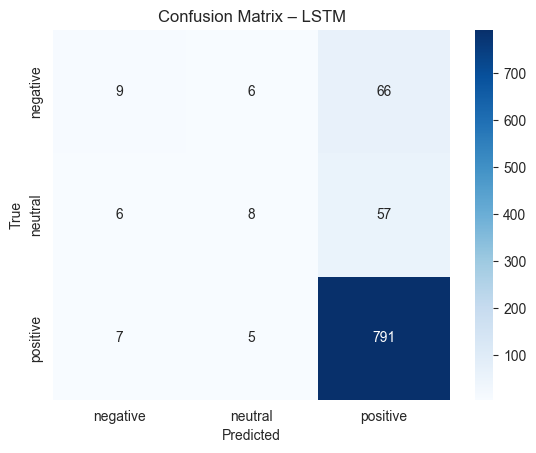

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – LSTM")
plt.show()

In [12]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import torch

In [13]:
tokenizer = AutoTokenizer.from_pretrained("../models/bert/distilbert")
model = AutoModelForSequenceClassification.from_pretrained(
    "../models/bert/distilbert"
)

model.eval()

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [14]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=256,
        return_tensors="pt"
    )

test_enc = tokenize({"text": test_df["text"].tolist()})

In [15]:
with torch.no_grad():
    outputs = model(
        input_ids=test_enc["input_ids"],
        attention_mask=test_enc["attention_mask"]
    )

y_pred = outputs.logits.argmax(dim=1).cpu().numpy()

In [16]:
y_true = test_df["sentiment"].values
id2label = model.config.id2label
y_pred_labels = [id2label[i] for i in y_pred]

print(classification_report(y_true, y_pred_labels))

              precision    recall  f1-score   support

    negative       0.60      0.58      0.59        81
     neutral       0.42      0.35      0.38        71
    positive       0.95      0.97      0.96       803

    accuracy                           0.89       955
   macro avg       0.66      0.63      0.64       955
weighted avg       0.88      0.89      0.88       955



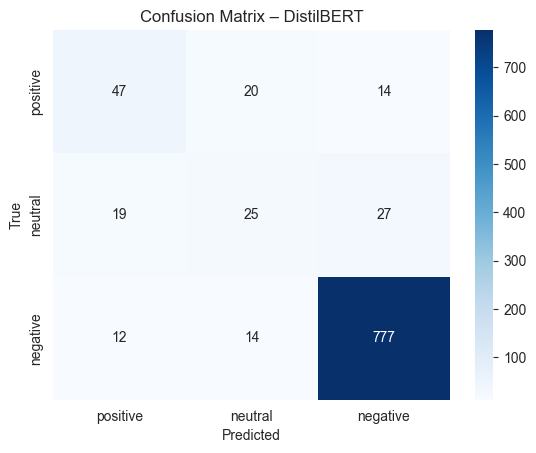

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_labels)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.config.id2label.values(),
    yticklabels=model.config.id2label.values()
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – DistilBERT")
plt.show()